In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [3]:
data = pd.read_csv('data_sales (1).csv')
data.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Sales Method
0,Walmart,1128299,6/17/2021,Southeast,Florida,Orlando,Women's Apparel,$103.00,218,"2,245","$1,257",Online
1,West Gear,1128299,7/16/2021,South,Louisiana,New Orleans,Women's Apparel,$103.00,163,"1,679",$806,Online
2,Sports Direct,1197831,8/25/2021,South,Alabama,Birmingham,Men's Street Footwear,$10.00,700,"7,000","$3,150",Outlet
3,Sports Direct,1197831,8/27/2021,South,Alabama,Birmingham,Women's Street Footwear,$15.00,575,"8,625","$3,881",Outlet
4,Sports Direct,1197831,8/21/2021,South,Alabama,Birmingham,Women's Street Footwear,$15.00,475,"7,125","$3,206",Outlet


In [4]:
data.shape

(9641, 12)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9641 entries, 0 to 9640
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9641 non-null   object
 1   Retailer ID       9641 non-null   int64 
 2   Invoice Date      9641 non-null   object
 3   Region            9641 non-null   object
 4   State             9641 non-null   object
 5   City              9641 non-null   object
 6   Product           9641 non-null   object
 7   Price per Unit    9639 non-null   object
 8   Units Sold        9641 non-null   object
 9   Total Sales       9641 non-null   object
 10  Operating Profit  9641 non-null   object
 11  Sales Method      9641 non-null   object
dtypes: int64(1), object(11)
memory usage: 904.0+ KB


In [6]:
cols = ['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']

data[cols] = data[cols].replace(r'[\$,]', '', regex=True).apply(pd.to_numeric, errors='coerce')

In [7]:
data['Price per Unit'] = data['Price per Unit'].fillna(data['Price per Unit'].mean().round())

In [8]:
data[['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']] = data[['Price per Unit', 'Units Sold', 'Total Sales', 'Operating Profit']].astype(int)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9641 entries, 0 to 9640
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9641 non-null   object
 1   Retailer ID       9641 non-null   int64 
 2   Invoice Date      9641 non-null   object
 3   Region            9641 non-null   object
 4   State             9641 non-null   object
 5   City              9641 non-null   object
 6   Product           9641 non-null   object
 7   Price per Unit    9641 non-null   int64 
 8   Units Sold        9641 non-null   int64 
 9   Total Sales       9641 non-null   int64 
 10  Operating Profit  9641 non-null   int64 
 11  Sales Method      9641 non-null   object
dtypes: int64(5), object(7)
memory usage: 904.0+ KB


In [10]:
data.describe().round()

,Retailer ID,Price per Unit,Units Sold,Total Sales,Operating Profit
count,9641.0,9641.0,9641.0,9641.0,9641.0
mean,1173851.0,45.0,257.0,9316.0,3439.0
std,26359.0,15.0,214.0,14183.0,5418.0
min,1128299.0,7.0,0.0,0.0,0.0
25%,1185732.0,35.0,106.0,425.0,192.0
50%,1185732.0,45.0,176.0,957.0,437.0
75%,1185732.0,55.0,350.0,15000.0,5200.0
max,1197831.0,110.0,1275.0,82500.0,39000.0


In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data['Retailer'].unique()

array(['Walmart', 'West Gear', 'Sports Direct', 'Foot Locker', 'Amazon',
       "Kohl's"], dtype=object)

In [13]:
data['Region'].unique()

array(['Southeast', 'South', 'Midwest', 'Northeast', 'West'], dtype=object)

In [14]:
data['Product'].unique()

array(["Women's Apparel", "Men's Street Footwear",
       "Women's Street Footwear", "Men's Athletic Footwear",
       "Women's Athletic Footwear", "Men's Apparel", "Men's aparel"],
      dtype=object)

In [15]:
data['Product'] = data['Product'].replace("Men's aparel", "Men's Apparel")
data['Product'].value_counts()

Product
Men's Street Footwear        1610
Men's Athletic Footwear      1608
Women's Apparel              1607
Women's Street Footwear      1606
Women's Athletic Footwear    1605
Men's Apparel                1605
Name: count, dtype: int64

# Analysis and Statistics

In [16]:
Retailer_Sales = data.groupby('Retailer')['Total Sales'].sum().sort_values(ascending = False).reset_index()
Retailer_Sales

,Retailer,Total Sales
0,West Gear,24204740
1,Foot Locker,21989528
2,Sports Direct,18188531
3,Kohl's,10211506
4,Amazon,7769912
5,Walmart,7455850


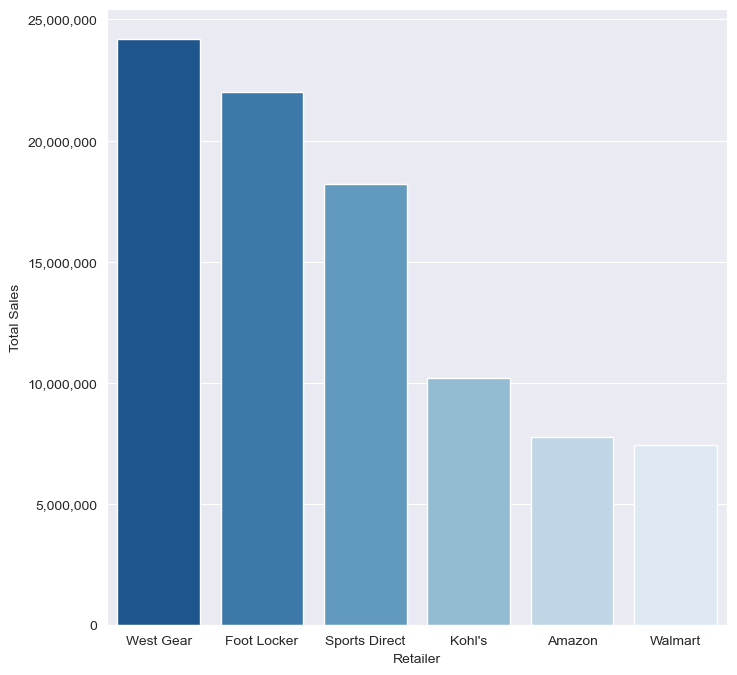

In [41]:
fig, ax= plt.subplots(figsize= (8,8))
ax= sns.barplot(x='Retailer', y= 'Total Sales', data= Retailer_Sales, estimator='sum', palette='Blues_r', hue='Retailer', legend=False)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
plt.show()

In [42]:
Retailer_Units = data.groupby(['Retailer', 'Sales Method'])['Units Sold'].sum().reset_index()
Retailer_Units

,Retailer,Sales Method,Units Sold
0,Amazon,In-store,40050
1,Amazon,Online,97859
2,Amazon,Outlet,60081
3,Foot Locker,In-store,160745
4,Foot Locker,Online,258150
5,Foot Locker,Outlet,185024
6,Kohl's,In-store,63370
7,Kohl's,Online,112721
8,Kohl's,Outlet,111284
9,Sports Direct,In-store,111370


C:\Users\Hania\AppData\Local\Temp\ipykernel_21996\2968081058.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax1 = sns.barplot(x='Units Sold', y='Retailer', data= Retailer_Units, color= 'darkblue', ci= None, palette='Blues' )
C:\Users\Hania\AppData\Local\Temp\ipykernel_21996\2968081058.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Units Sold', y='Retailer', data= Retailer_Units, color= 'darkblue', ci= None, palette='Blues' )


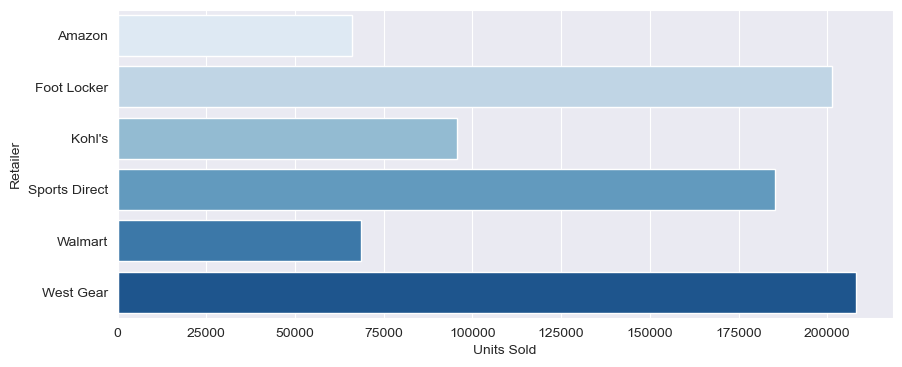

In [43]:
fig, ax1 = plt.subplots(figsize=(10,4))
ax1 = sns.barplot(x='Units Sold', y='Retailer', data= Retailer_Units, color= 'darkblue', ci= None, palette='Blues' )

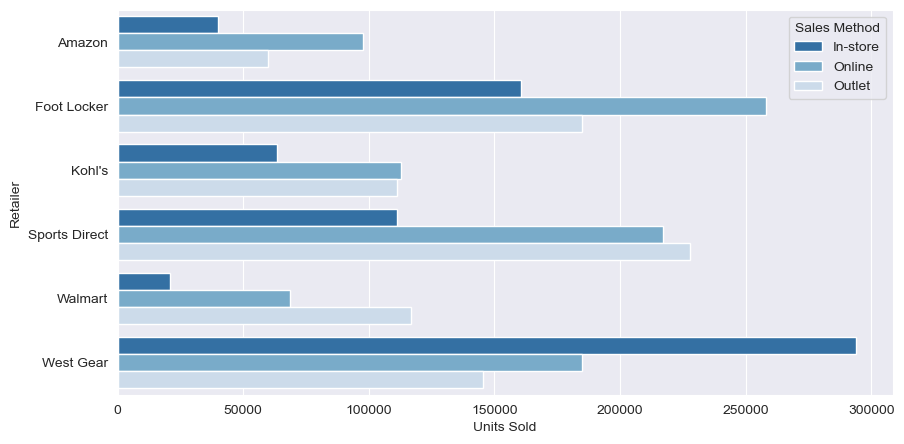

In [44]:
fig, ax2 = plt.subplots(figsize=(10,5))
ax2 = sns.barplot(x='Units Sold', y='Retailer', data= Retailer_Units, hue ='Sales Method', palette='Blues_r' )

plt.show()

In [45]:
data['Invoice Date']= pd.to_datetime(data['Invoice Date'])
q_sales= data.set_index('Invoice Date').resample('Q')['Total Sales'].sum().reset_index()

C:\Users\Hania\AppData\Local\Temp\ipykernel_21996\2735554651.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_sales= data.set_index('Invoice Date').resample('Q')['Total Sales'].sum().reset_index()


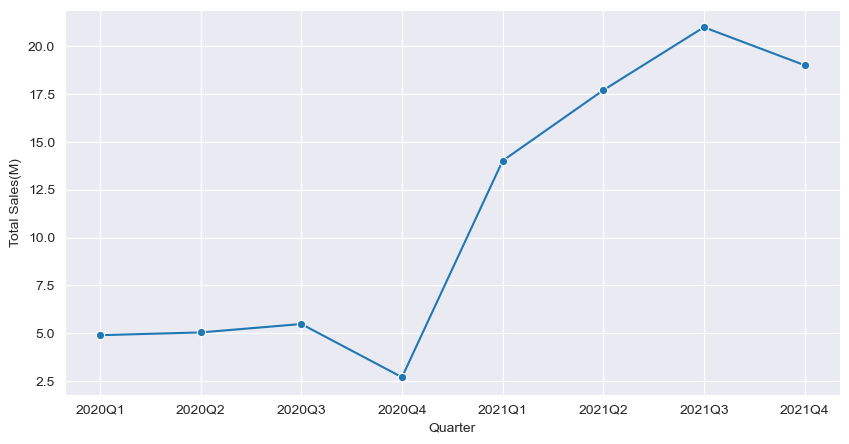

In [46]:
q_sales['Quarter'] = q_sales['Invoice Date'].dt.to_period('Q').astype(str)

sns.set_style('darkgrid')
fig, ax3= plt.subplots(figsize=(10,5))

ax3 = sns.lineplot(x='Quarter' , y=q_sales['Total Sales'] / 1e6, data= q_sales, marker= 'o')

plt.ylabel('Total Sales(M)')
plt.show()

In [47]:
data.to_csv('Adidas_Sales.csv')